In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import  dataloader

from tqdm import tqdm

from IPython.display import clear_output

data_path = './cifar10'
trainset = CIFAR10(root = data_path, train = True, download = True, transform = transforms.ToTensor())
testset = CIFAR10(root = data_path, train = False, download = True, transform = transforms.ToTensor())

100%|██████████| 170M/170M [00:03<00:00, 43.2MB/s]


In [ ]:
print(len(trainset), len(testset))

50000 10000


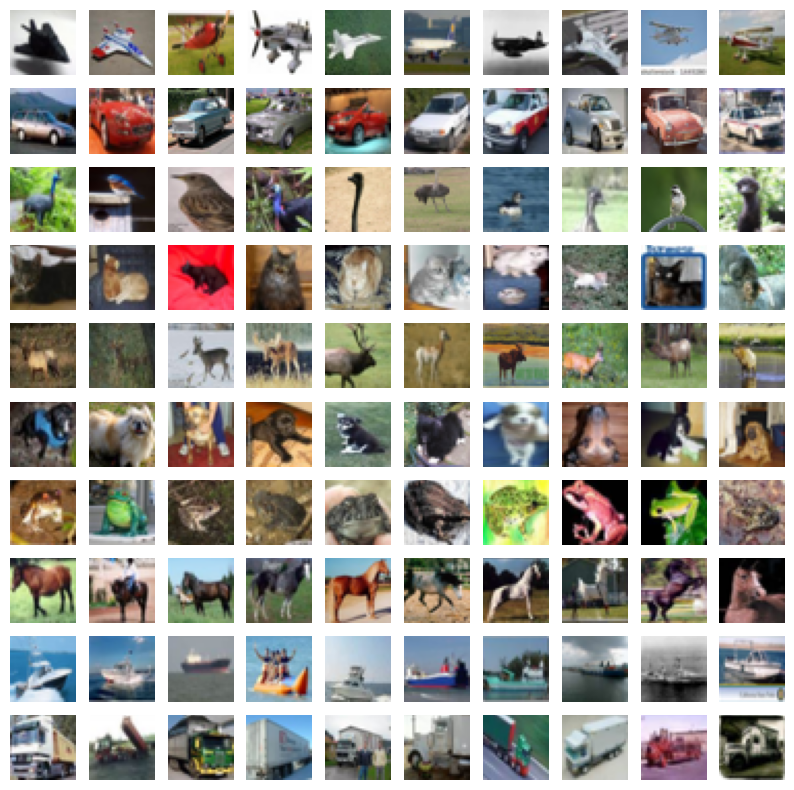

In [ ]:
num_classes = 10
fig, axes = plt.subplots(num_classes, 10, figsize = (10, 10))
labels = np.array([t[1] for t in trainset])
for i in range(num_classes):
  indices = np.where(labels == i)[0]
  for j in range(10):
    axes[i,j].imshow(trainset[indices[j]][0].permute(1,2,0).numpy())
    axes[i,j].axis('off')
plt.show()

In [ ]:
trainset[0][0].shape

torch.Size([3, 32, 32])

In [ ]:
class CNN(nn.Module):
  def __init__(self, num_classes):
    super(CNN, self).__init__()
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
    self.pooling1 = nn.MaxPool2d(kernel_size=2, stride=2)
    self.dropout1 = nn.Dropout(p=0.25)
    self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
    self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
    self.pooling2 = nn.MaxPool2d(kernel_size=2, stride=2)
    self.dropout2 = nn.Dropout(p=0.25)
    self.flatten = nn.Flatten()

    self.fc1 = nn.Linear(in_features=64*8*8, out_features=128)
    self.dropout3 = nn.Dropout(p=0.5)
    self.fc2 = nn.Linear(in_features=128, out_features=num_classes)
  def forward(self,x):
    x = F.relu(self.conv1(x))
    x = F.relu(self.conv2(x))
    x = self.pooling1(x)
    x = self.dropout1(x)
    x = F.relu(self.conv3(x))
    x = F.relu(self.conv4(x))
    x = self.pooling2(x)
    x = self.dropout2(x)
    x = self.flatten(x)
    x = F.relu(self.fc1(x))
    x = self.dropout3(x)
    x = self.fc2(x) ###  输出logits
    return x

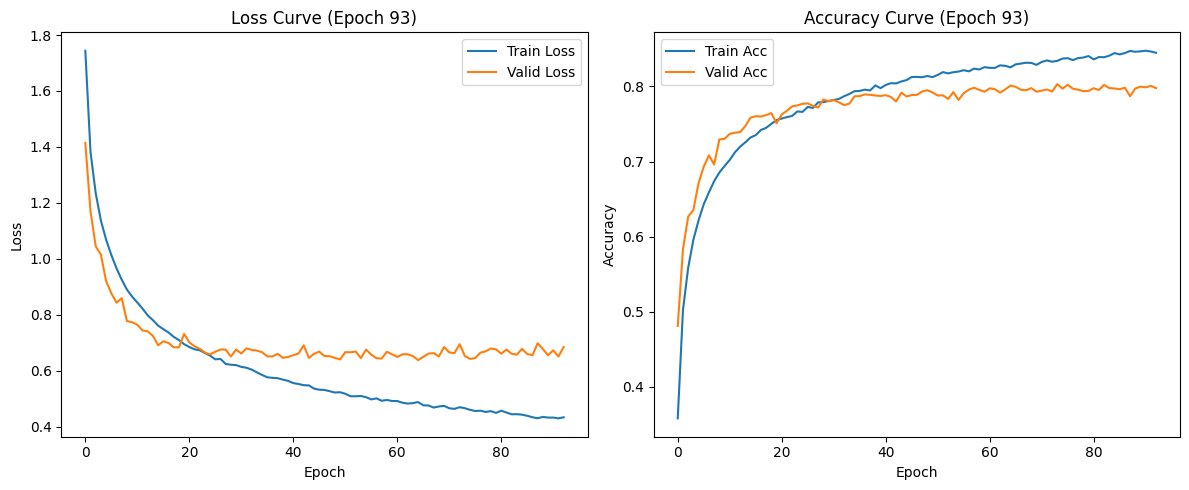

 10%|█         | 16/157 [00:00<00:03, 39.97it/s]

In [ ]:
### training
if not os.path.exists('./models'):
  os.mkdir('./models')

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
model = CNN(10)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_loader = dataloader.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=6, pin_memory=True)
test_loader = dataloader.DataLoader(testset, batch_size=64, shuffle=False, num_workers=6, pin_memory=True)
train_losses = []
train_acces = []
test_losses = []
test_acces = []
max_iters = 100
count = 0
best_acc = 0
for epoch in range(max_iters):
  train_loss = 0
  train_acc = 0
  model.train()
  for i, batch in (enumerate(tqdm(train_loader))):
    x, y = batch
    x = x.to(device)
    y = y.to(device)
    optimizer.zero_grad()
    logits = model(x)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    train_loss += loss.detach().item()
    train_preds = torch.argmax(logits, dim=1)
    train_acc += (train_preds.detach() == y).float().mean().item()
  train_losses.append(train_loss/len(train_loader))
  train_acces.append(train_acc/len(train_loader))

  if len(test_loader) > 0:
    test_loss = 0
    test_acc = 0
    model.eval()
    with torch.no_grad():
      for i, batch in (enumerate(tqdm(test_loader))):
        x, y = batch
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        test_loss += loss.item()
        test_preds = torch.argmax(logits, dim=1)
        test_acc += (test_preds == y).float().mean().item()
    test_losses.append(test_loss/len(test_loader))
    test_acces.append(test_acc/len(test_loader))

    if test_acc > best_acc:
      best_acc = test_acc
      torch.save(model.state_dict(), './models/best_model.pth')
      print(f"Saving model with best acc {best_acc}...")
      count = 0
    else:
      count += 1
      if count > 20:
        break

    # ===== 每隔 10 个 epoch 刷新一次图 =====
    if (epoch + 1) % 1 == 0 or epoch == 0:
        clear_output(wait=True)   # 清掉上一个图，不重刷整个页面

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Train Loss')
        if test_losses:
            plt.plot(test_losses, label='Valid Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title(f'Loss Curve (Epoch {epoch+1})')

        plt.subplot(1, 2, 2)
        plt.plot(train_acces, label='Train Acc')
        if test_acces:
            plt.plot(test_acces, label='Valid Acc')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.title(f'Accuracy Curve (Epoch {epoch+1})')

        plt.tight_layout()
        plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# from torchvison import models
from torchvision import models
import copy

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import  dataloader

from torchvision import  models
from torchvision.models import VGG16_Weights

from tqdm import tqdm

from IPython.display import clear_output

In [5]:
transform = transforms.Resize([512,512])

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
content_path = os.path.join('/content/drive/MyDrive/style_transfer', 'content', '04.jpg')
# print(content_path)
# plt.imread(content_path).shape
def loadingimg(path):
  img = plt.imread(path)
  img = torch.tensor(img).permute(2,0,1) ### C,H,W
  img = transform(img)
  plt.imshow(img.permute(1,2,0))
  print(img.shape)
  img = img.unsqueeze(0).float().float()
  img /= 255
  return img

torch.Size([3, 512, 512])


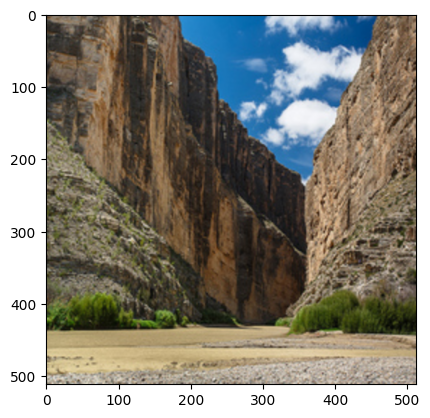

In [11]:
content_img = loadingimg(content_path)

torch.Size([3, 512, 512])


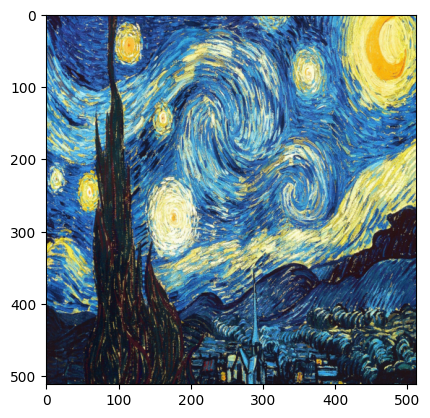

In [12]:
style_image_path = os.path.join('./drive/MyDrive/style_transfer', 'style.jpg')
style_img = loadingimg(style_image_path)

In [13]:
class ContentLoss(nn.Module):
  def __init__(self,target):
    super().__init__()
    self.target = target.detach() ### 从计算图分离 不是很理解
    self.criterion = nn.MSELoss() ### 实例化

  def forward(self,x):
    self.loss = self.criterion(x.clone(), self.target)
    return x

  def backward(self,retain_graph = True):
    self.loss.backward(retain_graph = retain_graph)
    return self.loss


In [14]:
def gram(x):
  batch_size, n, h, w = x.shape
  f = x.reshape(-1, h*w)
  return torch.matmul(f, f.T) / (batch_size * n * h *w)


In [15]:
class StyleLoss(nn.Module):
  def __init__(self, target):
    super().__init__()
    self.target_gram = gram(target).detach()
    self.criterion = nn.MSELoss()

  def forward(self, x):
    x_gram = gram(x.clone())
    self.loss = self.criterion(x_gram, self.target_gram)
    return x

  def backward(self, retain_graph = True):
    self.loss.backward(retain_graph = retain_graph)
    return self.loss

In [16]:
vgg16 = models.vgg16(weights=VGG16_Weights.DEFAULT).features

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 218MB/s]


In [17]:
vgg16

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [18]:
content_layer = ['Conv_13'] ### 对应着第五块的第三个卷积层
style_layer = ['Conv_1', 'Conv_3', 'Conv_5', 'Conv_8', 'Conv_11']### 第一到第五个块的第一个卷积层
content_losses = []
style_losses = []
model = nn.Sequential()
vgg16 = copy.deepcopy(vgg16)
index = 1
for layer in list(vgg16):
  if isinstance(layer, nn.Conv2d):
    name = 'Conv_' + str(index)
    model.add_module(name, layer)
    if name in content_layer:
      target = model(content_img).clone()
      content_loss = ContentLoss(target=target)
      model.append(content_loss)
      content_losses.append(content_loss)
    if name in style_layer:
      target = model(style_img).clone()
      style_loss = StyleLoss(target=target)
      model.append(style_loss)
      style_losses.append(style_loss)
  if isinstance(layer, nn.ReLU):
    name = 'ReLU_' + str(index)
    model.add_module(name, layer)
    index += 1

  if isinstance(layer, nn.MaxPool2d):
    name = 'MaxPool_' + str(index)
    model.add_module(name, layer)
    # index += 1
print(model)


Sequential(
  (Conv_1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): StyleLoss(
    (criterion): MSELoss()
  )
  (ReLU_1): ReLU(inplace=True)
  (Conv_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (ReLU_2): ReLU(inplace=True)
  (MaxPool_3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv_3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): StyleLoss(
    (criterion): MSELoss()
  )
  (ReLU_3): ReLU(inplace=True)
  (Conv_4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (ReLU_4): ReLU(inplace=True)
  (MaxPool_5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv_5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): StyleLoss(
    (criterion): MSELoss()
  )
  (ReLU_5): ReLU(inplace=True)
  (Conv_6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (ReLU_6): ReLU(inplace=True)


In [19]:
print(content_losses)
print(style_losses)

[ContentLoss(
  (criterion): MSELoss()
)]
[StyleLoss(
  (criterion): MSELoss()
), StyleLoss(
  (criterion): MSELoss()
), StyleLoss(
  (criterion): MSELoss()
), StyleLoss(
  (criterion): MSELoss()
), StyleLoss(
  (criterion): MSELoss()
)]


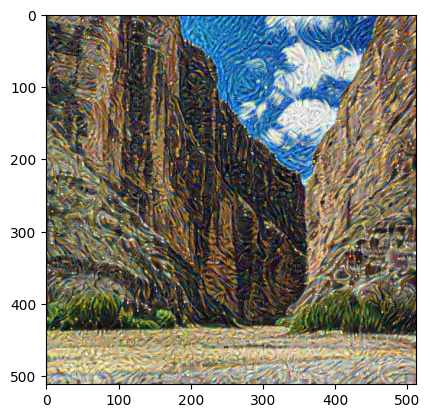

In [20]:
epochs = 50
learning_rate = 0.05
lbd = 1e6
input_img = content_img.clone()
para = nn.Parameter(input_img.data)
optimizer = torch.optim.Adam([para], lr=learning_rate)
for i in range(epochs):
  style_score = 0
  content_score = 0
  model(para)
  for cl in content_losses:
    content_score += cl.backward()
  for sl in style_losses:
    style_score += sl.backward()
  loss = content_score + lbd * style_score
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  para.data.clamp_(0,1)
  if i % 10 ==0 or i == epochs-1:
    clear_output(wait=True)
    plt.imshow(para.detach().squeeze(0).permute(1,2,0).numpy())
    plt.show()
